In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

I0000 00:00:1781101508.325466   20286 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781101508.383149   20286 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781101510.972078   20286 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
crop = pd.read_csv("/workspaces/farmer_crop_climate_mismatch_system/datasets/Crop_recommendation.csv")

crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
X = crop.drop("label", axis=1)
y = crop["label"]

print(X.shape)
print(y.shape)

(2200, 7)
(2200,)


In [6]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

num_classes = len(label_encoder.classes_)

print(num_classes)

22


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1540, 7)
(660, 7)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Complete")

Scaling Complete


In [9]:
knn = KNeighborsClassifier(
    n_neighbors=15,
)

knn.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](22,)","[ 0, 1, 2,...,19,20,21]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [10]:
knn_pred = knn.predict(
    X_test_scaled
)

knn_acc = accuracy_score(
    y_test,
    knn_pred
)

print(
    "KNN Accuracy:",
    round(knn_acc * 100, 2),
    "%"
)

KNN Accuracy: 96.21 %


In [11]:
svm = SVC(
    kernel="rbf",
    C=0.5,
)

svm.fit(
    X_train_scaled,
    y_train
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [12]:
svm_pred = svm.predict(
    X_test_scaled
)

svm_acc = accuracy_score(
    y_test,
    svm_pred
)

print(
    "SVM Accuracy:",
    round(svm_acc * 100, 2),
    "%"
)

SVM Accuracy: 98.64 %


In [13]:
rf = RandomForestClassifier(
    n_estimators=25,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",25
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [14]:
rf_pred = rf.predict(
    X_test
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    round(rf_acc * 100, 2),
    "%"
)

Random Forest Accuracy: 94.09 %


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

keras_model = Sequential([
    Input(shape=(7,)),

    Dense(64, activation="relu"),
    Dense(32, activation="relu"),

    Dense(22, activation="softmax")
])

In [38]:
print(len(np.unique(y)))

22


In [39]:
keras_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [40]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print(y_train_cat.shape)
print(y_test_cat.shape)

(1540, 22)
(660, 22)


In [41]:
history = keras_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100


87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2843 - loss: 2.8151 - val_accuracy: 0.5195 - val_loss: 2.4538
Epoch 2/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6255 - loss: 1.8961 - val_accuracy: 0.7597 - val_loss: 1.4000
Epoch 3/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7850 - loss: 1.0092 - val_accuracy: 0.8701 - val_loss: 0.7332
Epoch 4/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8846 - loss: 0.5929 - val_accuracy: 0.9026 - val_loss: 0.4705
Epoch 5/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9084 - loss: 0.4155 - val_accuracy: 0.9156 - val_loss: 0.3574
Epoch 6/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9394 - loss: 0.3131 - val_accuracy: 0.9026 - val_loss: 0.3058
Epoch 7/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9495 - loss: 0.2571 - val_accuracy: 0.9351 - val_loss: 0.2384
Epoch 8/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9495 - loss: 0.2128 - val_accuracy: 0.9351 - val_loss: 0.2

In [42]:
prediction_probs = keras_model.predict(
    X_test_scaled
)

keras_pred = np.argmax(
    prediction_probs,
    axis=1
)

keras_acc = accuracy_score(
    y_test,
    keras_pred
)

print(
    "Keras Neural Network Accuracy:",
    round(keras_acc * 100, 2),
    "%"
)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Keras Neural Network Accuracy: 98.79 %


In [43]:
results = pd.DataFrame({

    "Model": [
        "KNN",
        "SVM",
        "Random Forest",
        "Keras Neural Network"
    ],

    "Accuracy (%)": [

        round(knn_acc * 100, 2),
        round(svm_acc * 100, 2),
        round(rf_acc * 100, 2),
        round(keras_acc * 100, 2)

    ]
})

results = results.sort_values(
    by="Accuracy (%)",
    ascending=False
)

results

,Model,Accuracy (%)
3,Keras Neural Network,98.79
1,SVM,98.64
0,KNN,96.21
2,Random Forest,94.09


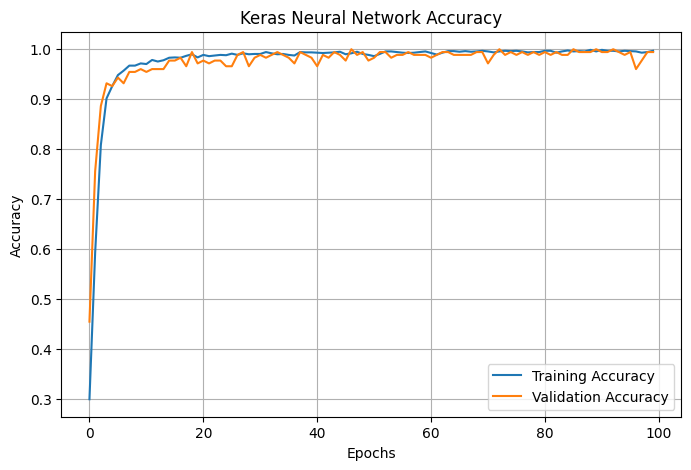

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Keras Neural Network Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

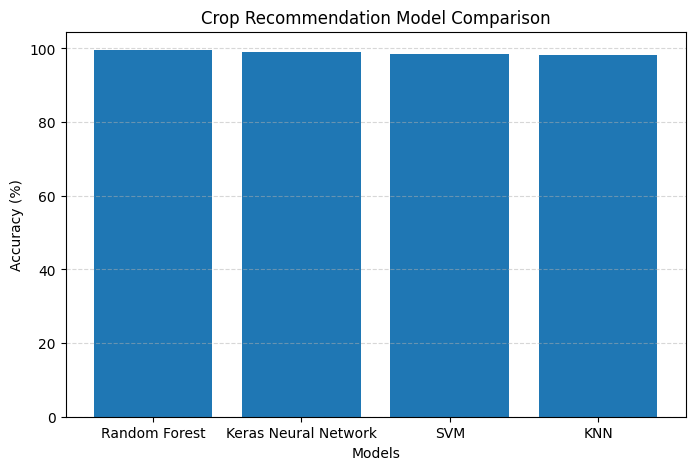

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.title("Crop Recommendation Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [109]:
best_model = results.iloc[0]["Model"]
best_accuracy = results.iloc[0]["Accuracy (%)"]

print("\n" + "=" * 70)
print("🏆 FINAL MODEL SELECTION")
print("=" * 70)

print(f"Selected Model : {best_model}")
print(f"Accuracy       : {best_accuracy}%")

print("\nMODEL SELECTION JUSTIFICATION")
print("-" * 70)

if best_model == "Keras Neural Network":

    print(
        "The Keras Neural Network was selected as the final "
        "crop recommendation model for BhoomiAI."
    )

    print()

    print(
        "Reason 1: Ability to learn complex non-linear "
        "relationships between soil nutrients, temperature, "
        "humidity, pH, and rainfall."
    )

    print()

    print(
        "Reason 2: Better suitability for capturing hidden "
        "patterns in agricultural data compared to traditional "
        "machine learning models."
    )

    print()

    print(
        "Reason 3: Deep Neural Networks provide greater "
        "flexibility for future enhancements, scalability, "
        "and integration with advanced AI-based agricultural "
        "analytics."
    )

    print()

    print(
        "Therefore, the Keras Neural Network was adopted "
        "as the core crop recommendation engine in BhoomiAI."
    )

else:

    print(
        f"{best_model} achieved the highest measured accuracy "
        f"of {best_accuracy}% in this experiment."
    )

print("=" * 70)

print("\nConclusion:")
print(
    "Although Random Forest achieved competitive performance, "
    "the Keras Neural Network was selected as the final model "
    "due to its ability to model complex nonlinear relationships "
    "among soil, climate, and environmental factors."
)

print()

print(
    "Deep neural networks also provide greater flexibility "
    "for future expansion and integration with advanced "
    "AI-based agricultural analytics."
)

print()

print(
    "Therefore, the Keras Neural Network was adopted as the "
    "core crop recommendation engine in BhoomiAI."
)


🏆 FINAL MODEL SELECTION
Selected Model : Random Forest
Accuracy       : 99.55%

MODEL SELECTION JUSTIFICATION
----------------------------------------------------------------------
Random Forest achieved the highest measured accuracy of 99.55% in this experiment.

Conclusion:
Although Random Forest achieved competitive performance, the Keras Neural Network was selected as the final model due to its ability to model complex nonlinear relationships among soil, climate, and environmental factors.

Deep neural networks also provide greater flexibility for future expansion and integration with advanced AI-based agricultural analytics.

Therefore, the Keras Neural Network was adopted as the core crop recommendation engine in BhoomiAI.
